# Customer Churn Prediction using Machine Learning

## Project Overview
This project analyzes customer churn in a telecommunications company using the **Telco Customer Churn** dataset. The goal is to build a machine learning model that predicts whether a customer will churn (leave the service) based on their demographics, account information, and subscribed services.

## Dataset
- **Source**: [Telco Customer Churn — Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
- **Records**: 7,043 customers × 21 features
- **Target Variable**: Churn (Yes / No)

## Approach
1. Data Understanding & Cleaning
2. Exploratory Data Analysis (Univariate + Bivariate)
3. Data Preprocessing (Encoding, Train-Test Split, SMOTE, Undersampling)
4. Model Training (Logistic Regression, Decision Tree, Random Forest, XGBoost)
5. Stratified K-Fold Cross-Validation & Hyperparameter Tuning
6. Model Evaluation (ROC, Precision-Recall, Feature Importance, Learning Curves)
7. Predictive System (End-to-end inference pipeline)
8. Business Conclusions & Recommendations

**1. Importing the dependencies**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (train_test_split, cross_val_score,
                                      StratifiedKFold, GridSearchCV,
                                      RandomizedSearchCV, learning_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                              f1_score, roc_auc_score, roc_curve, precision_recall_curve)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import pickle
import warnings
warnings.filterwarnings('ignore')

**2. Data Loading and Understanding**

In [2]:
# Load the CSV data to a pandas DataFrame
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.shape

(7043, 21)

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
pd.set_option("display.max_columns", None)

In [6]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [8]:
# dropping customerID column as this is not required for modelling
df = df.drop(columns=["customerID"])

In [9]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [10]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [11]:
print(df["gender"].unique())

<StringArray>
['Female', 'Male']
Length: 2, dtype: str


In [12]:
print(df["SeniorCitizen"].unique())

[0 1]


In [13]:
# printing the unique values in all the columns

numerical_features_list = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in df.columns:
  if col not in numerical_features_list:
    print(col, df[col].unique())
    print("-"*50)

gender <StringArray>
['Female', 'Male']
Length: 2, dtype: str
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner <StringArray>
['Yes', 'No']
Length: 2, dtype: str
--------------------------------------------------
Dependents <StringArray>
['No', 'Yes']
Length: 2, dtype: str
--------------------------------------------------
PhoneService <StringArray>
['No', 'Yes']
Length: 2, dtype: str
--------------------------------------------------
MultipleLines <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
--------------------------------------------------
InternetService <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
--------------------------------------------------
OnlineSecurity <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
--------------------------------------------------
OnlineBackup <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, 

In [14]:
print(df.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [15]:
df[df["TotalCharges"]==" "]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [16]:
len(df[df["TotalCharges"]==" "])

11

In [17]:
df["TotalCharges"] = df["TotalCharges"].replace({" ": "0.0"})

In [18]:
df["TotalCharges"] = df["TotalCharges"].astype(float)

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [20]:
# checking the class distribution of target column
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


**Insights:**
1. Customer ID removed as it is not required for modelling
2. No missing values in the dataset
3. Missing values in the TotalCharges column were replaced with 0
4. Class imbalance identified in the target (73.5% No Churn vs 26.5% Churn)

**3. Exploratory Data Analysis (EDA)**

In [21]:
df.shape

(7043, 20)

In [22]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [23]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


In [24]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


**Numerical Features - Analysis**

Understand the distribution of teh numerical features

In [25]:
def plot_histogram(df, column_name):

  plt.figure(figsize=(5, 3))
  sns.histplot(df[column_name], kde=True)
  plt.title(f"Distribution of {column_name}")

  # calculate the mean and median values for the columns
  col_mean = df[column_name].mean()
  col_median = df[column_name].median()

  # add vertical lines for mean and median
  plt.axvline(col_mean, color="red", linestyle="--", label="Mean")
  plt.axvline(col_median, color="green", linestyle="-", label="Median")

  plt.legend()

  plt.show()

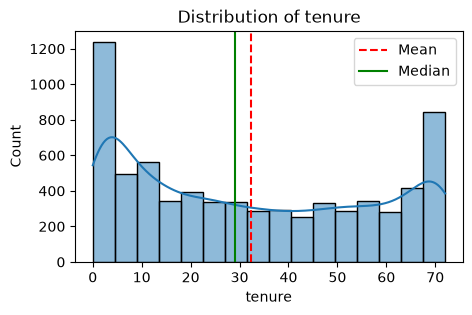

In [26]:
plot_histogram(df, "tenure")

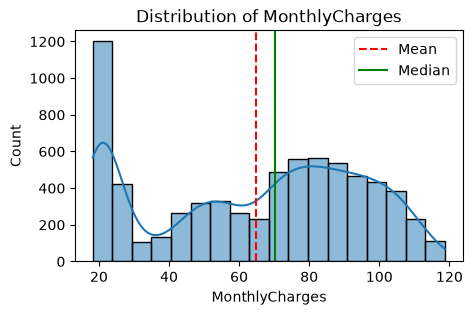

In [27]:
plot_histogram(df, "MonthlyCharges")

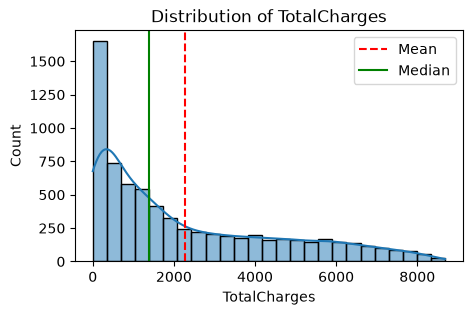

In [28]:
plot_histogram(df, "TotalCharges")

**Box plot for numerical features**

In [29]:
def plot_boxplot(df, column_name):

  plt.figure(figsize=(5, 3))
  sns.boxplot(y=df[column_name])
  plt.title(f"Box Plot of {column_name}")
  plt.ylabel(column_name)
  plt.show()

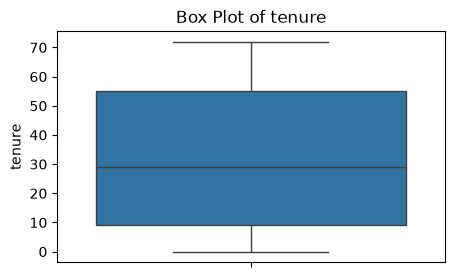

In [30]:
plot_boxplot(df, "tenure")

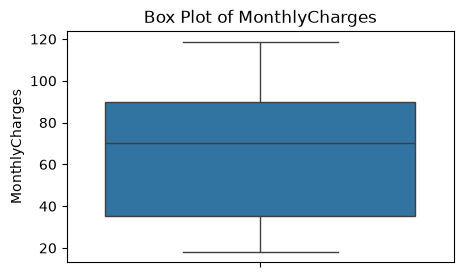

In [31]:
plot_boxplot(df, "MonthlyCharges")

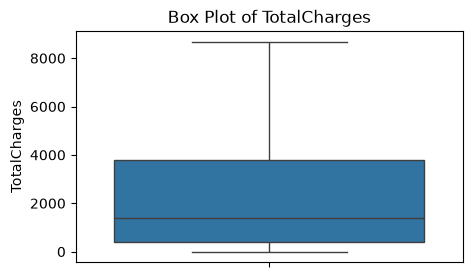

In [32]:
plot_boxplot(df, "TotalCharges")

**Correlation Heatmap for numerical columns**

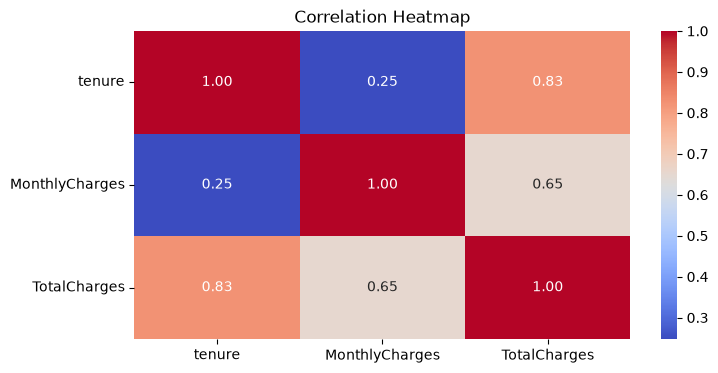

In [33]:
# correlation matrix - heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Categorical features - Analysis

In [34]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

Countplot for categorical columns

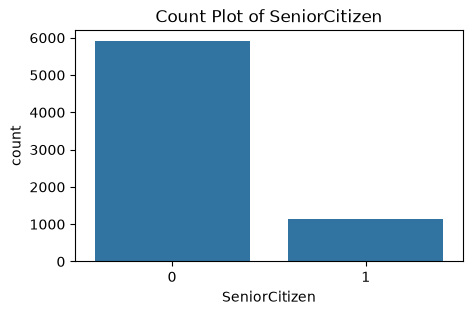

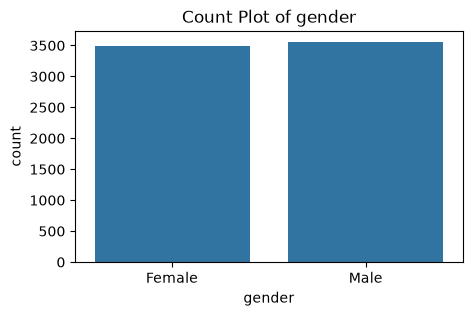

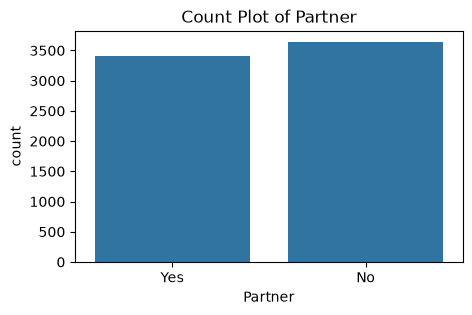

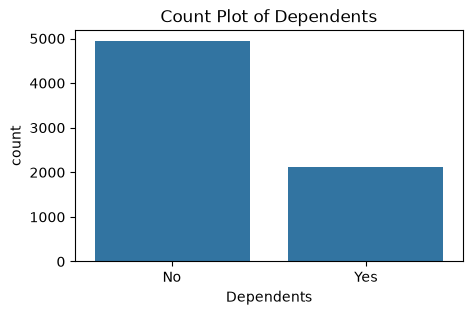

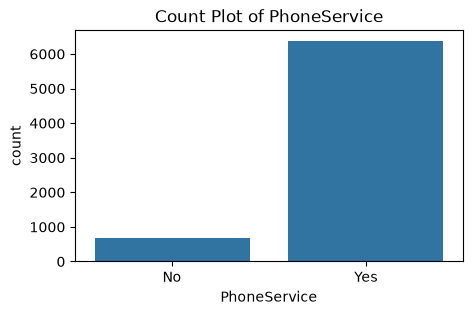

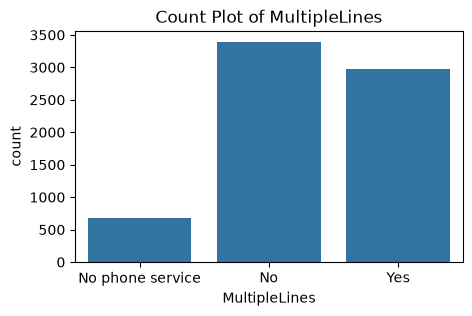

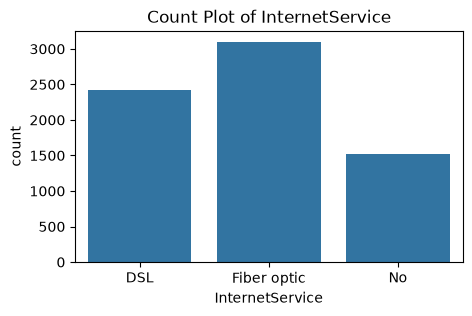

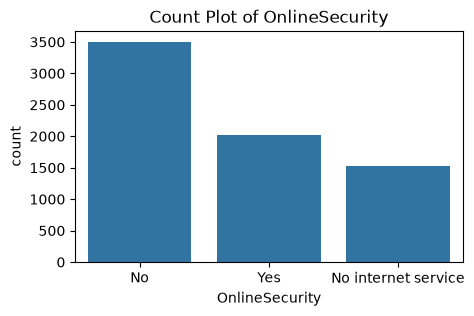

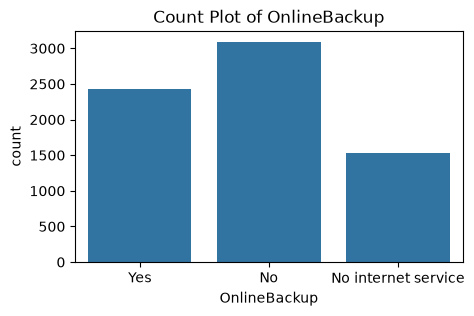

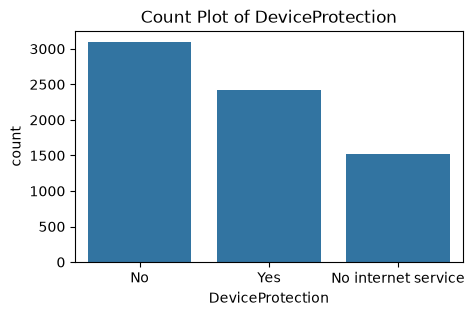

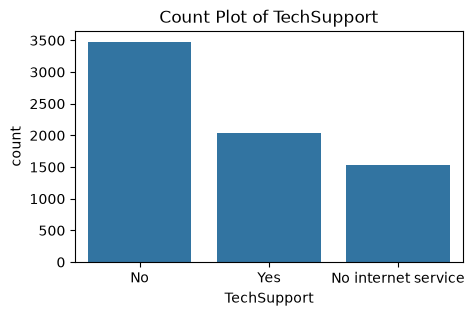

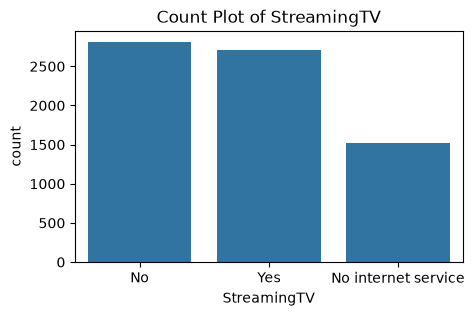

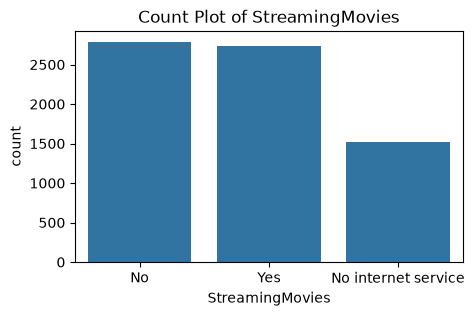

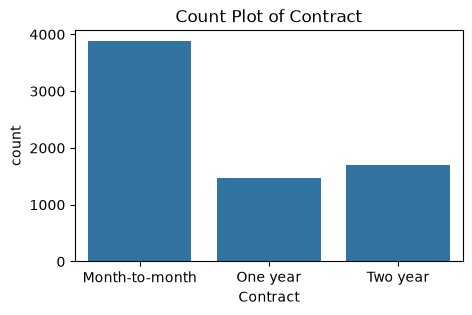

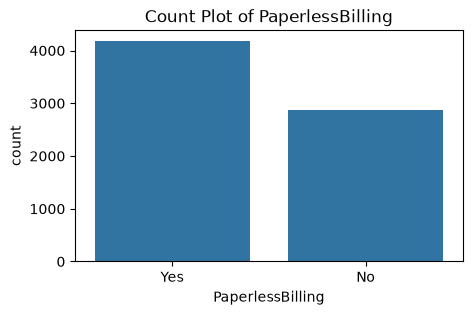

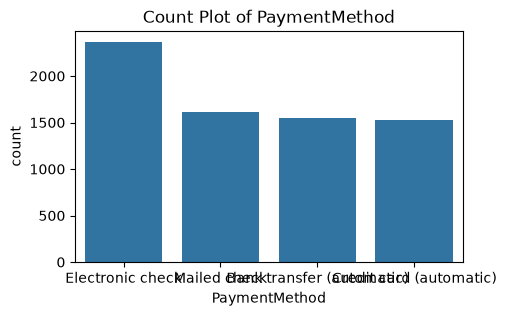

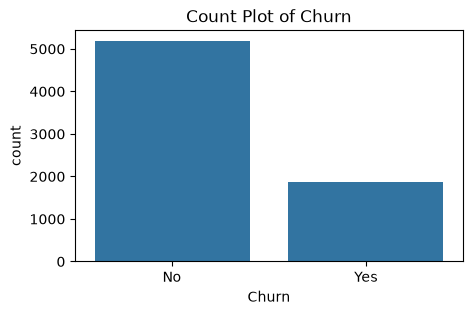

In [36]:
object_cols = df.select_dtypes(include="object").columns.to_list()

object_cols = ["SeniorCitizen"] + object_cols

for col in object_cols:
  plt.figure(figsize=(5, 3))
  sns.countplot(x=df[col])
  plt.title(f"Count Plot of {col}")
  plt.show()

**Bivariate Analysis — Churn Rate by Feature**

Analyzing how different features correlate with churn to identify key drivers.

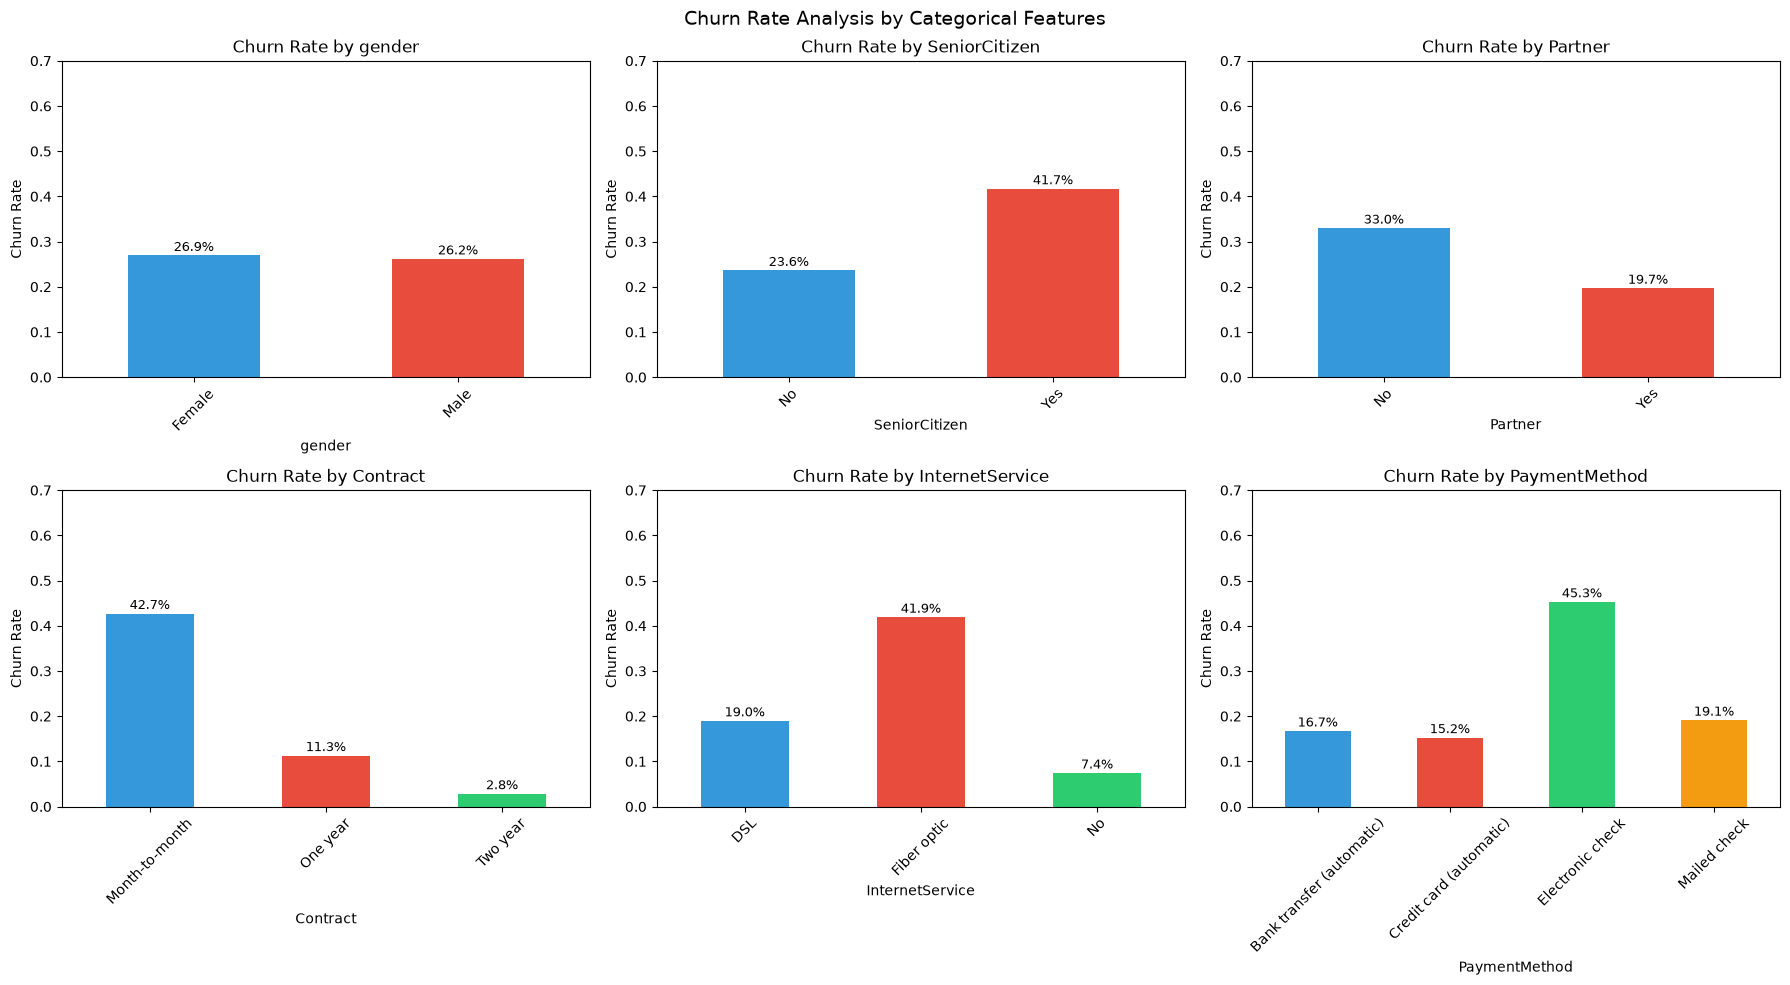

In [37]:
# Churn Rate by Key Categorical Features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
bivariate_features = ['gender', 'SeniorCitizen', 'Partner', 'Contract', 'InternetService', 'PaymentMethod']

for idx, col in enumerate(bivariate_features):
    ax = axes[idx // 3][idx % 3]
    if col == 'SeniorCitizen':
        temp = df.copy()
        temp['SeniorCitizen'] = temp['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
        churn_rate = temp.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean())
    else:
        churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean())
    bars = churn_rate.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'][:len(churn_rate)])
    ax.set_title(f'Churn Rate by {col}', fontsize=12)
    ax.set_ylabel('Churn Rate')
    ax.set_ylim(0, 0.7)
    ax.tick_params(axis='x', rotation=45)
    for i, v in enumerate(churn_rate):
        ax.text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=9)

plt.suptitle('Churn Rate Analysis by Categorical Features', fontsize=14)
plt.tight_layout()
plt.show()

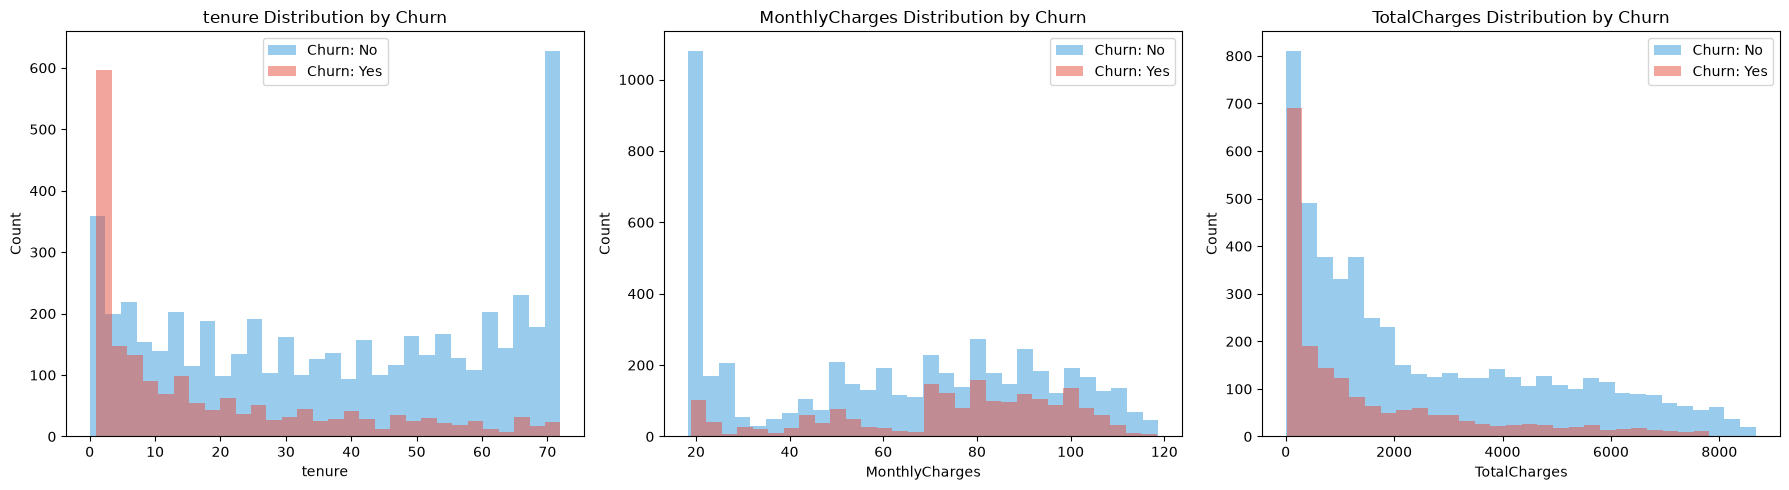

In [38]:
# Distribution of Numerical Features by Churn Status
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for idx, col in enumerate(num_cols):
    for label, color in zip(['No', 'Yes'], ['#3498db', '#e74c3c']):
        subset = df[df['Churn'] == label][col]
        axes[idx].hist(subset, bins=30, alpha=0.5, label=f'Churn: {label}', color=color)
    axes[idx].set_title(f'{col} Distribution by Churn', fontsize=12)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    axes[idx].legend()

plt.tight_layout()
plt.show()

**Target Variable Distribution**

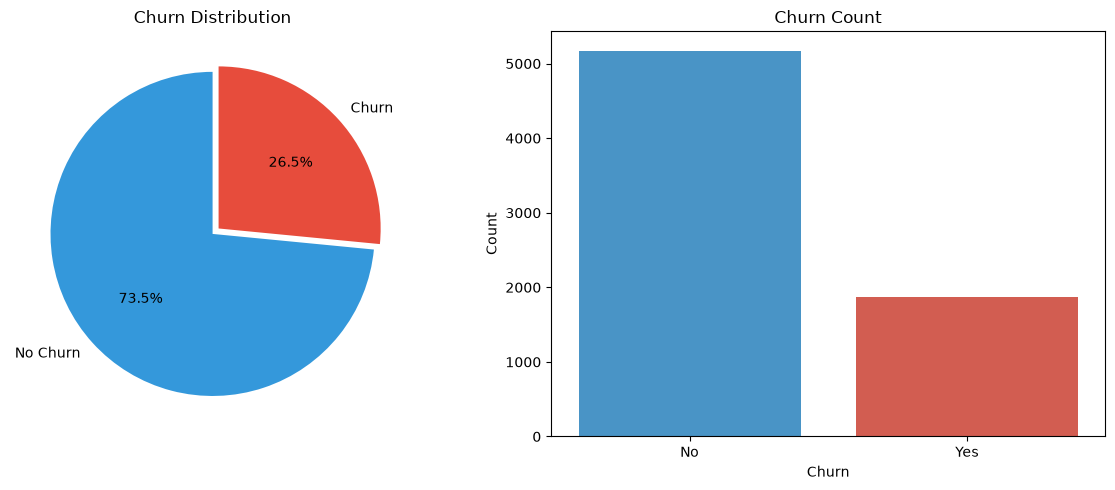

In [39]:
# Target Variable Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

churn_counts = df['Churn'].value_counts()
axes[0].pie(churn_counts, labels=['No Churn', 'Churn'], autopct='%1.1f%%',
            colors=['#3498db', '#e74c3c'], startangle=90, explode=(0, 0.05))
axes[0].set_title('Churn Distribution', fontsize=12)

sns.countplot(x='Churn', data=df, ax=axes[1], palette=['#3498db', '#e74c3c'])
axes[1].set_title('Churn Count', fontsize=12)
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

**4. Data Preprocessing**

In [40]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


Label encoding of target column

In [41]:
df["Churn"] = df["Churn"].replace({"Yes": 1, "No": 0})

In [42]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


In [43]:
print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


Label encoding of categorical features

In [44]:
# identifying columns with object data type
object_columns = df.select_dtypes(include="object").columns

In [45]:
print(object_columns)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')


In [46]:
# initialize a dictionary to save the encoders
encoders = {}

# apply label encoding and store the encoders
for column in object_columns:
  label_encoder = LabelEncoder()
  df[column] = label_encoder.fit_transform(df[column])
  encoders[column] = label_encoder


# save the encoders to a pickle file
with open("encoders.pkl", "wb") as f:
  pickle.dump(encoders, f)


In [47]:
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder(),
 'Churn': LabelEncoder()}

In [48]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


**Training and Test Data Split**

In [49]:
# splitting the features and target
X = df.drop(columns=["Churn"])
y = df["Churn"]

In [50]:
# Split training and test data with stratification to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [51]:
print(y_train.shape)

(5634,)


In [52]:
print(y_train.value_counts())

Churn
0    4139
1    1495
Name: count, dtype: int64


**Synthetic Minority Oversampling Technique (SMOTE)**

In [53]:
smote = SMOTE(random_state=42)

In [54]:
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [55]:
print(y_train_smote.shape)

(8278,)


In [56]:
print(y_train_smote.value_counts())

Churn
0    4139
1    4139
Name: count, dtype: int64


**Random Undersampling**

As an alternative to SMOTE, we also create an undersampled training set for comparison.

In [57]:
# Random Undersampling for comparison
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print(f"Undersampled training set size: {X_train_under.shape[0]}")
print(y_train_under.value_counts())

Undersampled training set size: 2990
Churn
0    1495
1    1495
Name: count, dtype: int64


**Note on Feature Scaling**

Feature scaling (StandardScaler) is important for distance-based and gradient-based models like **Logistic Regression** and SVM. Tree-based models (Decision Tree, Random Forest, XGBoost) are inherently invariant to feature scaling.

In this project, we use a `Pipeline` with `StandardScaler` for Logistic Regression to ensure proper scaling, while tree-based models use the data as-is.

**5. Model Training**

**5.1 Baseline Model Comparison (Stratified K-Fold CV)**

Comparing 4 models using Stratified 5-Fold Cross-Validation with **F1 score** (better than accuracy for imbalanced data) and **ROC-AUC**. Logistic Regression uses a Pipeline with StandardScaler.

In [58]:
# Define Stratified K-Fold Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define models — Pipeline with StandardScaler for Logistic Regression
models = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss')
}

# Cross-validate each model using F1 and ROC-AUC
cv_results = {}
print(f"{'Model':<25} {'Mean F1':>10} {'Std F1':>10} {'Mean AUC':>10}")
print("=" * 60)

for name, model in models.items():
    f1_scores = cross_val_score(model, X_train_smote, y_train_smote, cv=skf, scoring='f1')
    auc_scores = cross_val_score(model, X_train_smote, y_train_smote, cv=skf, scoring='roc_auc')
    cv_results[name] = {
        'f1_mean': f1_scores.mean(),
        'f1_std': f1_scores.std(),
        'auc_mean': auc_scores.mean(),
        'auc_std': auc_scores.std()
    }
    print(f"{name:<25} {f1_scores.mean():>10.4f} {f1_scores.std():>10.4f} {auc_scores.mean():>10.4f}")

Model                        Mean F1     Std F1   Mean AUC


Logistic Regression           0.8103     0.0061     0.8862


Decision Tree                 0.7945     0.0088     0.7923


Random Forest                 0.8508     0.0051     0.9266


XGBoost                       0.8485     0.0079     0.9273


**5.2 Model Comparison Visualization**

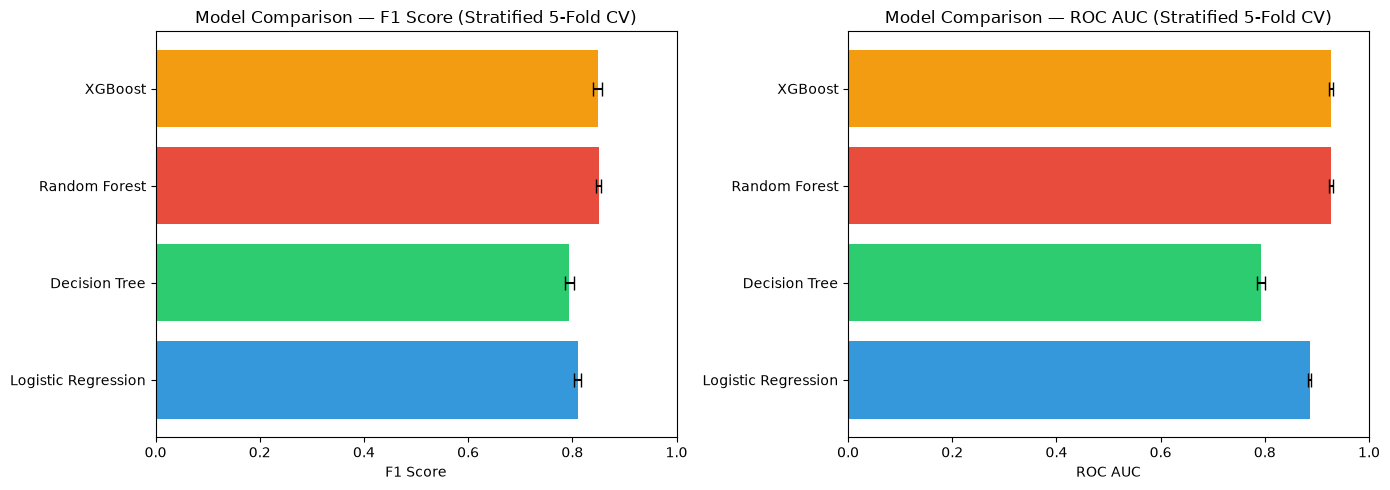

In [59]:
# Model Comparison Visualization
results_df = pd.DataFrame(cv_results).T
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(results_df.index, results_df['f1_mean'], xerr=results_df['f1_std'],
             color=colors, capsize=5)
axes[0].set_xlabel('F1 Score')
axes[0].set_title('Model Comparison — F1 Score (Stratified 5-Fold CV)')
axes[0].set_xlim(0, 1)

axes[1].barh(results_df.index, results_df['auc_mean'], xerr=results_df['auc_std'],
             color=colors, capsize=5)
axes[1].set_xlabel('ROC AUC')
axes[1].set_title('Model Comparison — ROC AUC (Stratified 5-Fold CV)')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

**5.3 Hyperparameter Tuning**

Tuning the top-performing tree-based models:
- **Random Forest**: GridSearchCV (exhaustive search)
- **XGBoost**: RandomizedSearchCV (efficient for large parameter spaces)

In [60]:
# Hyperparameter Tuning — Random Forest (GridSearchCV)
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=skf,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_search_rf.fit(X_train_smote, y_train_smote)

print(f"\nBest Random Forest Parameters: {grid_search_rf.best_params_}")
print(f"Best CV F1 Score: {grid_search_rf.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits



Best Random Forest Parameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1 Score: 0.8539


In [61]:
# Hyperparameter Tuning — XGBoost (RandomizedSearchCV)
param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

random_search_xgb = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_dist_xgb,
    n_iter=50,
    cv=skf,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)
random_search_xgb.fit(X_train_smote, y_train_smote)

print(f"\nBest XGBoost Parameters: {random_search_xgb.best_params_}")
print(f"Best CV F1 Score: {random_search_xgb.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits



Best XGBoost Parameters: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best CV F1 Score: 0.8547


**5.4 Default vs Tuned Comparison**

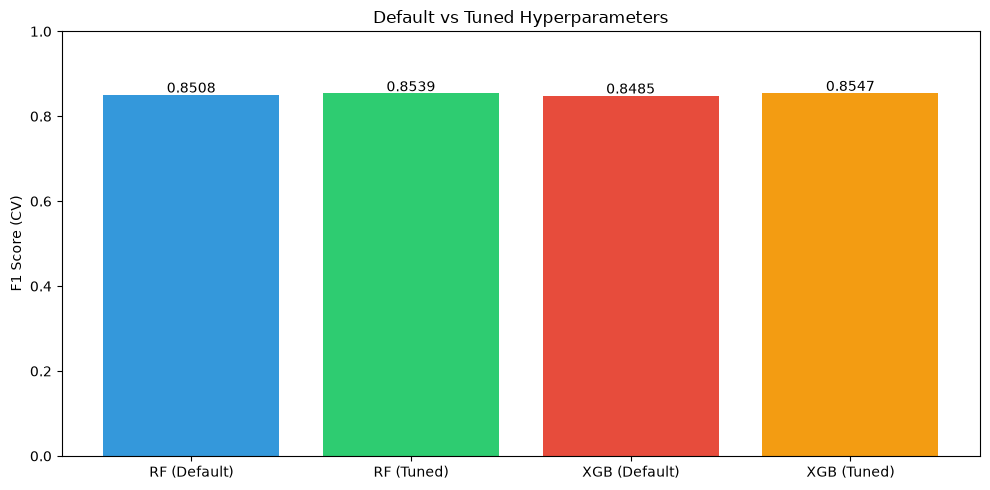

In [62]:
# Default vs Tuned Comparison
comparison = {
    'RF (Default)': cv_results['Random Forest']['f1_mean'],
    'RF (Tuned)': grid_search_rf.best_score_,
    'XGB (Default)': cv_results['XGBoost']['f1_mean'],
    'XGB (Tuned)': random_search_xgb.best_score_,
}

plt.figure(figsize=(10, 5))
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
bars = plt.bar(comparison.keys(), comparison.values(), color=colors)
plt.ylabel('F1 Score (CV)')
plt.title('Default vs Tuned Hyperparameters')
for bar, val in zip(bars, comparison.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', fontsize=10)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

**5.5 Resampling Strategy Comparison**

Comparing the impact of different class imbalance handling strategies on model performance.

Resampling Strategy Comparison (Random Forest, Stratified 5-Fold CV, F1)


Strategy                Mean F1     Std F1
---------------------------------------------
No Resampling            0.5407     0.0248
SMOTE                    0.8508     0.0051
Undersampling            0.7470     0.0115


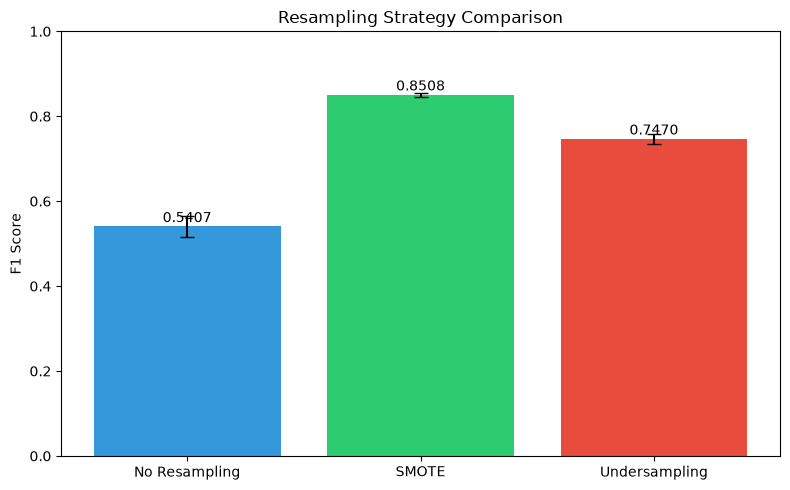

In [63]:
# Resampling Strategy Comparison using Random Forest
print("Resampling Strategy Comparison (Random Forest, Stratified 5-Fold CV, F1)")
print("=" * 65)

skf_cmp = StratifiedKFold(5, shuffle=True, random_state=42)

scores_none = cross_val_score(
    RandomForestClassifier(random_state=42), X_train, y_train,
    cv=skf_cmp, scoring='f1')

scores_smote = cross_val_score(
    RandomForestClassifier(random_state=42), X_train_smote, y_train_smote,
    cv=skf_cmp, scoring='f1')

scores_under = cross_val_score(
    RandomForestClassifier(random_state=42), X_train_under, y_train_under,
    cv=skf_cmp, scoring='f1')

print(f"{'Strategy':<20} {'Mean F1':>10} {'Std F1':>10}")
print("-" * 45)
print(f"{'No Resampling':<20} {scores_none.mean():>10.4f} {scores_none.std():>10.4f}")
print(f"{'SMOTE':<20} {scores_smote.mean():>10.4f} {scores_smote.std():>10.4f}")
print(f"{'Undersampling':<20} {scores_under.mean():>10.4f} {scores_under.std():>10.4f}")

# Visualize
strategies = ['No Resampling', 'SMOTE', 'Undersampling']
means = [scores_none.mean(), scores_smote.mean(), scores_under.mean()]
stds = [scores_none.std(), scores_smote.std(), scores_under.std()]

plt.figure(figsize=(8, 5))
bars = plt.bar(strategies, means, yerr=stds, color=['#3498db', '#2ecc71', '#e74c3c'], capsize=5)
plt.ylabel('F1 Score')
plt.title('Resampling Strategy Comparison')
for bar, m in zip(bars, means):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{m:.4f}', ha='center', fontsize=10)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

**5.6 Final Model Selection**

In [64]:
# Select the best model based on CV F1 score
best_rf = grid_search_rf.best_estimator_
best_xgb = random_search_xgb.best_estimator_

tuned_models = {
    'Tuned Random Forest': (best_rf, grid_search_rf.best_score_),
    'Tuned XGBoost': (best_xgb, random_search_xgb.best_score_)
}

best_model_name = max(tuned_models, key=lambda x: tuned_models[x][1])
final_model = tuned_models[best_model_name][0]

print(f"Selected Best Model: {best_model_name}")
print(f"CV F1 Score: {tuned_models[best_model_name][1]:.4f}")

if best_model_name == 'Tuned Random Forest':
    print(f"Best Parameters: {grid_search_rf.best_params_}")
else:
    print(f"Best Parameters: {random_search_xgb.best_params_}")

Selected Best Model: Tuned XGBoost
CV F1 Score: 0.8547
Best Parameters: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


**6. Model Evaluation**

In [65]:
print(y_test.value_counts())

Churn
0    1035
1     374
Name: count, dtype: int64


**6.1 Overfitting Check (Train vs Test)**

In [66]:
# Overfitting Check: Train vs Test Performance
y_train_pred = final_model.predict(X_train_smote)
y_test_pred = final_model.predict(X_test)

train_acc = accuracy_score(y_train_smote, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
train_f1 = f1_score(y_train_smote, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

print(f"{'Metric':<20} {'Train':>10} {'Test':>10} {'Gap':>10}")
print("=" * 55)
print(f"{'Accuracy':<20} {train_acc:>10.4f} {test_acc:>10.4f} {train_acc - test_acc:>10.4f}")
print(f"{'F1 Score':<20} {train_f1:>10.4f} {test_f1:>10.4f} {train_f1 - test_f1:>10.4f}")

if train_f1 - test_f1 > 0.10:
    print("\n Warning: Significant overfitting detected (F1 gap > 10%)")
elif train_f1 - test_f1 > 0.05:
    print("\n Warning: Mild overfitting detected (F1 gap 5-10%)")
else:
    print("\n No significant overfitting detected")

Metric                    Train       Test        Gap
Accuracy                 0.9826     0.7743     0.2083
F1 Score                 0.9828     0.5794     0.4034



**6.2 Classification Report**

In [67]:
# Detailed Classification Report
y_pred_proba = final_model.predict_proba(X_test)[:, 1]

print(f"Model: {best_model_name}")
print("=" * 60)
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_test_pred):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=['No Churn', 'Churn']))

Model: Tuned XGBoost
Accuracy:  0.7743
F1 Score:  0.5794
ROC AUC:   0.8197

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.84      0.85      1035
       Churn       0.57      0.59      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.78      0.77      0.78      1409



**6.3 Confusion Matrix**

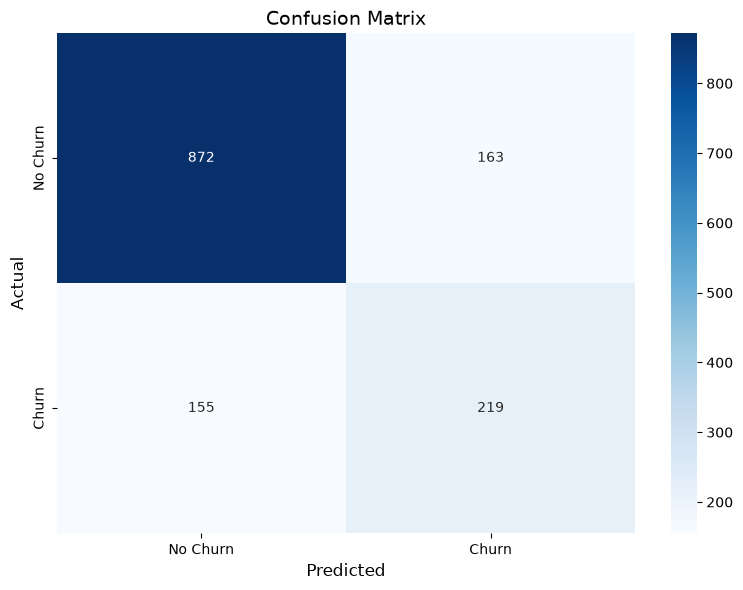

In [68]:
# Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.show()

**6.4 ROC Curve**

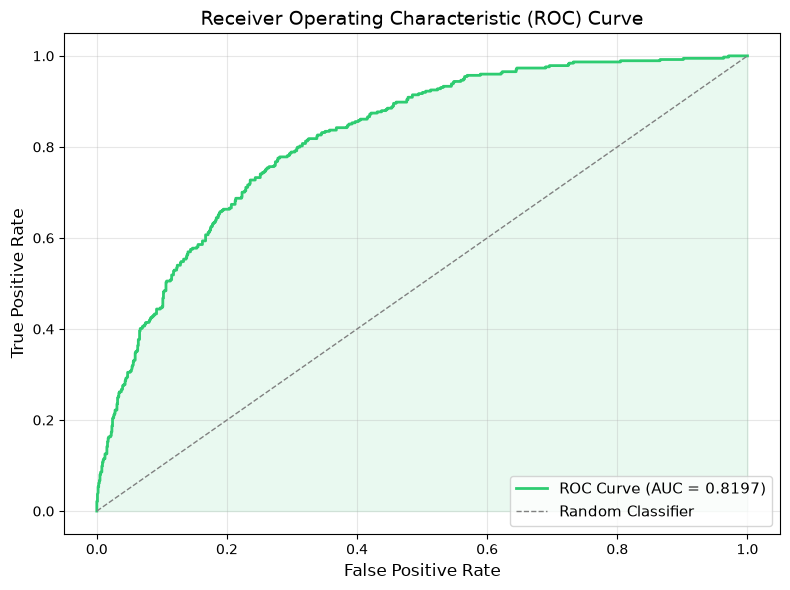

In [69]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#2ecc71', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='#2ecc71')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**6.5 Precision-Recall Curve**

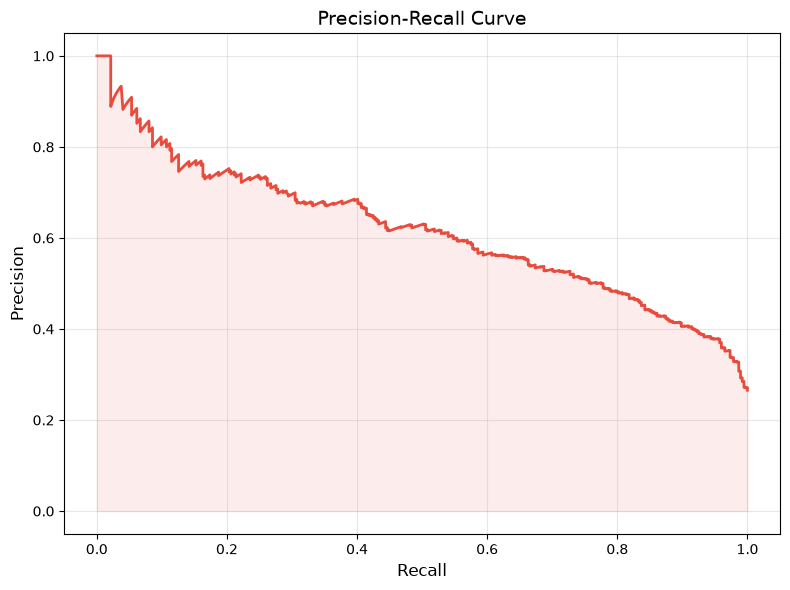

In [70]:
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='#e74c3c', lw=2)
plt.fill_between(recall, precision, alpha=0.1, color='#e74c3c')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**6.6 Feature Importance**

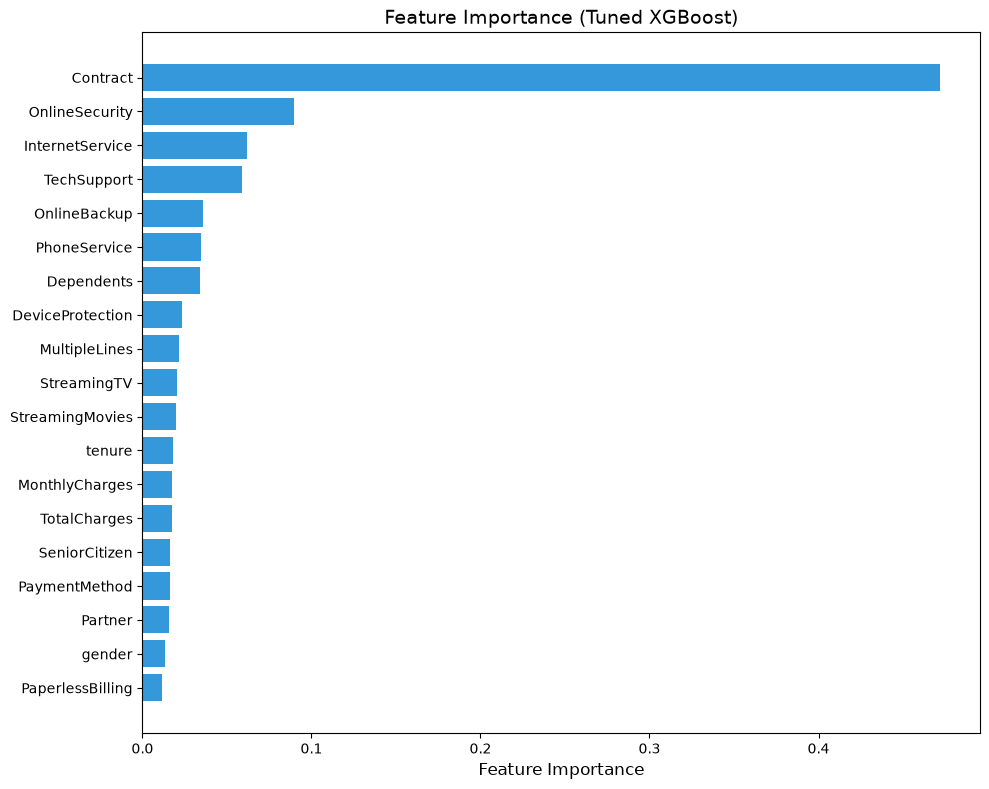


Top 5 Most Important Features for Churn Prediction:
--------------------------------------------------
  Contract                  Importance: 0.4719
  OnlineSecurity            Importance: 0.0898
  InternetService           Importance: 0.0619
  TechSupport               Importance: 0.0589
  OnlineBackup              Importance: 0.0358


In [71]:
# Feature Importance Analysis
importances = final_model.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='#3498db')
plt.xlabel('Feature Importance', fontsize=12)
plt.title(f'Feature Importance ({best_model_name})', fontsize=14)
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features for Churn Prediction:")
print("-" * 50)
for _, row in feat_imp.tail(5).iloc[::-1].iterrows():
    print(f"  {row['Feature']:<25} Importance: {row['Importance']:.4f}")

**6.7 Learning Curves**

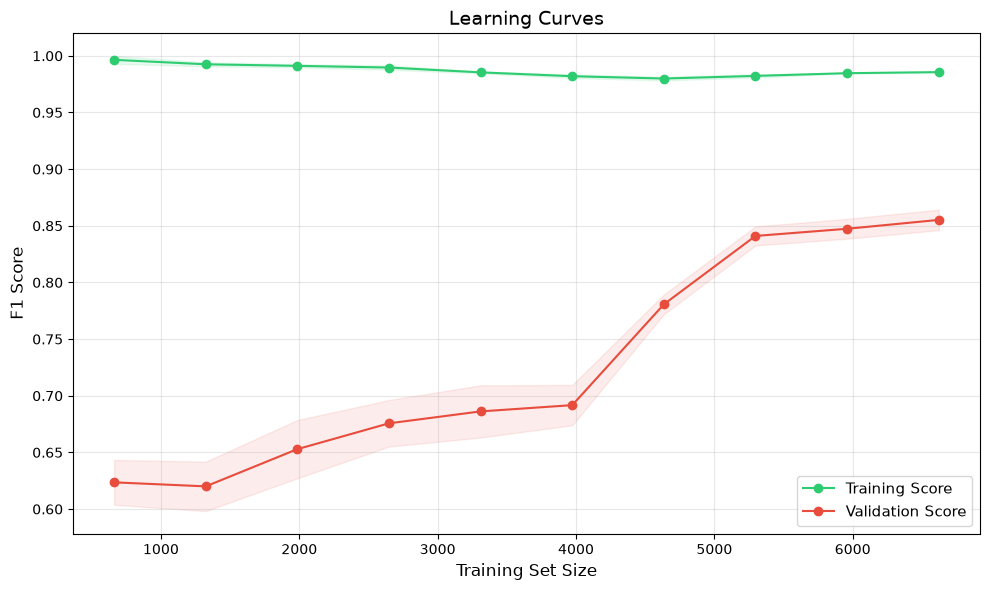

In [72]:
# Learning Curves — assess overfitting/underfitting visually
train_sizes_arr, train_scores, val_scores = learning_curve(
    final_model, X_train_smote, y_train_smote,
    cv=skf, train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='f1', n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes_arr, train_mean - train_std, train_mean + train_std,
                 alpha=0.1, color='#2ecc71')
plt.fill_between(train_sizes_arr, val_mean - val_std, val_mean + val_std,
                 alpha=0.1, color='#e74c3c')
plt.plot(train_sizes_arr, train_mean, 'o-', color='#2ecc71', label='Training Score')
plt.plot(train_sizes_arr, val_mean, 'o-', color='#e74c3c', label='Validation Score')
plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title('Learning Curves', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [73]:
# Save the final trained model
model_data = {"model": final_model, "features_names": X.columns.tolist()}

with open("customer_churn_model.pkl", "wb") as f:
    pickle.dump(model_data, f)

print(f"Model '{best_model_name}' saved successfully as 'customer_churn_model.pkl'")

Model 'Tuned XGBoost' saved successfully as 'customer_churn_model.pkl'


**7. Load the saved  model and  build a Predictive System**

In [74]:
# Load the saved model and feature names

with open("customer_churn_model.pkl", "rb") as f:
  model_data = pickle.load(f)

loaded_model = model_data["model"]
feature_names = model_data["features_names"]

In [75]:
print(loaded_model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)


In [76]:
print(feature_names)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [77]:
input_data = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 1,
    'PhoneService': 'No',
    'MultipleLines': 'No phone service',
    'InternetService': 'DSL',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 29.85,
    'TotalCharges': 29.85
}


input_data_df = pd.DataFrame([input_data])

with open("encoders.pkl", "rb") as f:
  encoders = pickle.load(f)


# Encode categorical features using the saved encoders
for column, encoder in encoders.items():
  if column in input_data_df.columns:
    input_data_df[column] = encoder.transform(input_data_df[column])

# Make a prediction
prediction = loaded_model.predict(input_data_df)
pred_prob = loaded_model.predict_proba(input_data_df)

print(prediction)

# Results
print(f"Prediction: {'Churn' if prediction[0] == 1 else 'No Churn'}")


[0]
Prediction: No Churn


In [78]:
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder(),
 'Churn': LabelEncoder()}

## 8. Business Conclusions & Recommendations

### Key Findings

1. **Churn Drivers**: The feature importance analysis reveals the top factors influencing customer churn, including contract type, tenure, monthly charges, and internet service type.

2. **Contract Impact**: Month-to-month contract customers have significantly higher churn rates compared to those on longer-term contracts.

3. **Tenure Effect**: Customers with shorter tenure (< 12 months) are the most likely to churn, suggesting the early months are critical for retention.

4. **Service Add-ons**: Customers lacking services like Online Security and Tech Support show higher churn tendencies.

### Business Recommendations

1. **Contract Incentives**: Offer discounts or benefits to encourage month-to-month customers to switch to annual or two-year contracts.
2. **Early Engagement Programs**: Implement targeted onboarding and engagement programs for new customers within their first 12 months.
3. **Service Bundling**: Promote add-on services (Online Security, Tech Support, Online Backup) as retention tools with discounted bundles.
4. **Payment Method Optimization**: Encourage customers using electronic checks to switch to automatic payment methods, which correlate with lower churn.
5. **Proactive Retention**: Use the model's churn probability scores to identify at-risk customers and trigger proactive retention campaigns before they leave.

### Model Limitations & Future Work

- **Data Limitations**: The model is trained on historical data and may not capture future market dynamics or competitive changes.
- **Feature Engineering**: Additional features (customer lifetime value, usage patterns, complaint history) could improve predictive power.
- **Model Retraining**: The model should be periodically retrained to adapt to evolving customer behavior.
- **Explainability**: Implement SHAP (SHapley Additive exPlanations) for more granular, instance-level feature importance.
- **Production Deployment**: Consider building a REST API or Streamlit app for real-time churn scoring.